# Data Profiling and Quality

This notebook profiles the local NYC TLC Green Taxi monthly parquet files and records evidence for later MLOps decisions. It intentionally does not finalize the prediction target, split strategy, model family, quality thresholds, or drift thresholds.

## Business Problem

The project is a Green Taxi trip prediction proof of concept organized as an MLOps workflow. The business objective is still exploratory: candidate targets include trip duration, fare amount, total amount, or a derived long-trip/high-fare classification target.

Notebook 1 answers whether the data is suitable for those later choices by checking coverage, schema stability, missing values, invalid-looking records, and serving-time feature availability.

## Dataset Description

- Source page: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
- Green Taxi parquet URL pattern: `https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_YYYY-MM.parquet`
- Taxi zone lookup: `https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv`
- Local raw files: `data/01_raw/green_taxi/YYYY/green_tripdata_YYYY-MM.parquet`
- Local metadata file: `data/01_raw/metadata/taxi_zone_lookup.csv`

The local project currently contains Green Taxi data from 2024-01 through 2026-04. TLC documentation notes that 2025 onward includes `cbd_congestion_fee`, so this notebook explicitly checks schema changes across years.

## Loading the Data

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from green_taxi_mlops.profiling import (
    add_trip_derived_columns,
    candidate_target_summary,
    discover_green_taxi_files,
    exploratory_numeric_summary,
    load_green_taxi_data,
    missing_value_summary,
    monthly_temporal_summary,
    quality_check_summary,
    read_parquet_metadata,
    save_artifacts,
    schema_presence_summary,
    serving_time_column_classification,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

RAW_DIR = PROJECT_ROOT / "data" / "01_raw" / "green_taxi"
ZONE_LOOKUP_PATH = PROJECT_ROOT / "data" / "01_raw" / "metadata" / "taxi_zone_lookup.csv"
REPORT_DIR = PROJECT_ROOT / "data" / "08_reporting" / "profiling"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Set to an integer for faster future sampling. None loads all local files.
ROWS_PER_FILE = None

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Report directory: {REPORT_DIR}")

Project root: C:\Users\Asus\Documents\MLOPS Project\mlops-project
Raw data directory: C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi
Report directory: C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling


In [2]:
files = discover_green_taxi_files(RAW_DIR)
assert not files.empty, f"No Green Taxi parquet files found under {RAW_DIR}"

monthly_metadata, schema = read_parquet_metadata(files)
schema_summary = schema_presence_summary(schema)

display(files)
display(monthly_metadata[["period", "row_count", "column_count", "file_size_bytes"]].head())
display(monthly_metadata[["period", "row_count", "column_count", "file_size_bytes"]].tail())

print(f"Files discovered: {len(files)}")
print(f"Coverage: {files['period'].min()} to {files['period'].max()}")
print(f"Total rows from parquet metadata: {monthly_metadata['row_count'].sum():,}")

,year,month,period,path,file_size_bytes
0,2024,1,2024-01,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-01.parquet,1362284
1,2024,2,2024-02,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-02.parquet,1283805
2,2024,3,2024-03,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-03.parquet,1372372
3,2024,4,2024-04,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-04.parquet,1346502
4,2024,5,2024-05,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-05.parquet,1453912
5,2024,6,2024-06,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-06.parquet,1326194
6,2024,7,2024-07,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-07.parquet,1250973
7,2024,8,2024-08,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-08.parquet,1267079
8,2024,9,2024-09,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-09.parquet,1326186
9,2024,10,2024-10,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\01_raw\green_taxi\2024\green_tripdata_2024-10.parquet,1353731


,period,row_count,column_count,file_size_bytes
0,2024-01,56551,20,1362284
1,2024-02,53577,20,1283805
2,2024-03,57457,20,1372372
3,2024-04,56471,20,1346502
4,2024-05,61003,20,1453912


,period,row_count,column_count,file_size_bytes
23,2025-12,48236,21,1171145
24,2026-01,40272,21,991656
25,2026-02,37373,21,920753
26,2026-03,44208,21,1082530
27,2026-04,44238,21,1075896


Files discovered: 28
Coverage: 2024-01 to 2026-04
Total rows from parquet metadata: 1,417,684


## Initial Data Checks

In [3]:
display(schema_summary)

columns_not_in_all_months = schema_summary.loc[~schema_summary["present_in_all_periods"]]
display(columns_not_in_all_months)

cbd_row = schema_summary.loc[schema_summary["column"].eq("cbd_congestion_fee")]
display(cbd_row)

if not cbd_row.empty:
    print("cbd_congestion_fee first appears in:", cbd_row.iloc[0]["first_period"])
else:
    print("cbd_congestion_fee is not present in the local raw files.")

,column,period_count,first_period,last_period,dtypes,missing_period_count,present_in_all_periods
0,cbd_congestion_fee,16,2025-01,2026-04,double,12,False
1,DOLocationID,28,2024-01,2026-04,int32,0,True
2,PULocationID,28,2024-01,2026-04,int32,0,True
3,RatecodeID,28,2024-01,2026-04,int64,0,True
4,VendorID,28,2024-01,2026-04,int32,0,True
5,congestion_surcharge,28,2024-01,2026-04,double,0,True
6,ehail_fee,28,2024-01,2026-04,double,0,True
7,extra,28,2024-01,2026-04,double,0,True
8,fare_amount,28,2024-01,2026-04,double,0,True
9,improvement_surcharge,28,2024-01,2026-04,double,0,True


,column,period_count,first_period,last_period,dtypes,missing_period_count,present_in_all_periods
0,cbd_congestion_fee,16,2025-01,2026-04,double,12,False


,column,period_count,first_period,last_period,dtypes,missing_period_count,present_in_all_periods
0,cbd_congestion_fee,16,2025-01,2026-04,double,12,False


cbd_congestion_fee first appears in: 2025-01


In [4]:
taxi = load_green_taxi_data(files, rows_per_file=ROWS_PER_FILE)
taxi = add_trip_derived_columns(taxi)

print(f"Loaded shape: {taxi.shape}")
display(taxi.head())
display(taxi.dtypes.astype(str).reset_index().rename(columns={"index": "column", 0: "dtype"}))

Loaded shape: (1417684, 27)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,source_year,source_month,source_period,cbd_congestion_fee,trip_duration_minutes,pickup_date,pickup_hour
0,2,2024-01-01 00:46:55,2024-01-01 00:58:25,N,1.0,236,239,1.0,1.98,12.8,1.0,0.5,3.61,0.0,NaN,1.0,21.66,1.0,1.0,2.75,2024,1,2024-01,NaN,11.500000,2024-01-01,0
1,2,2024-01-01 00:31:42,2024-01-01 00:52:34,N,1.0,65,170,5.0,6.54,30.3,1.0,0.5,7.11,0.0,NaN,1.0,42.66,1.0,1.0,2.75,2024,1,2024-01,NaN,20.866667,2024-01-01,0
2,2,2024-01-01 00:30:21,2024-01-01 00:49:23,N,1.0,74,262,1.0,3.08,19.8,1.0,0.5,3.00,0.0,NaN,1.0,28.05,1.0,1.0,2.75,2024,1,2024-01,NaN,19.033333,2024-01-01,0
3,1,2024-01-01 00:30:20,2024-01-01 00:42:12,N,1.0,74,116,1.0,2.40,14.2,1.0,1.5,0.00,0.0,NaN,1.0,16.70,2.0,1.0,0.00,2024,1,2024-01,NaN,11.866667,2024-01-01,0
4,2,2024-01-01 00:32:38,2024-01-01 00:43:37,N,1.0,74,243,1.0,5.14,22.6,1.0,0.5,6.28,0.0,NaN,1.0,31.38,1.0,1.0,0.00,2024,1,2024-01,NaN,10.983333,2024-01-01,0


,column,dtype
0,VendorID,int32
1,lpep_pickup_datetime,datetime64[us]
2,lpep_dropoff_datetime,datetime64[us]
3,store_and_fwd_flag,str
4,RatecodeID,float64
5,PULocationID,int32
6,DOLocationID,int32
7,passenger_count,float64
8,trip_distance,float64
9,fare_amount,float64


,source_period,rows,pickup_min,pickup_max,dropoff_min,dropoff_max
0,2024-01,56551,2023-12-31 14:38:47,2024-01-31 23:57:29,2023-12-31 14:46:45,2024-02-01 19:17:30
1,2024-02,53577,2024-01-25 19:10:32,2024-02-29 23:56:40,2024-01-25 19:25:11,2024-03-01 19:56:23
2,2024-03,57457,2008-12-31 23:02:24,2024-04-01 00:01:45,2008-12-31 23:02:30,2024-04-01 16:11:00
3,2024-04,56471,2024-03-31 22:34:23,2024-04-30 23:59:33,2024-03-31 22:45:33,2024-05-01 23:35:25
4,2024-05,61003,2009-01-01 00:27:54,2024-06-01 00:00:56,2009-01-01 00:32:44,2024-06-01 21:12:50
5,2024-06,54748,2024-05-24 17:04:38,2024-06-30 23:57:10,2024-05-24 17:18:40,2024-07-01 19:48:38
6,2024-07,51837,2024-06-30 23:55:13,2024-08-01 23:43:58,2024-07-01 00:12:56,2024-08-01 23:52:36
7,2024-08,51771,2024-07-25 22:29:43,2024-09-01 20:26:14,2024-07-25 22:56:07,2024-09-01 22:36:59
8,2024-09,54440,2008-12-31 00:00:00,2024-10-01 23:42:50,2008-12-31 00:00:00,2024-10-01 23:48:50
9,2024-10,56147,2024-09-26 01:59:36,2024-11-01 23:06:08,2024-09-26 01:59:57,2024-11-01 23:17:09


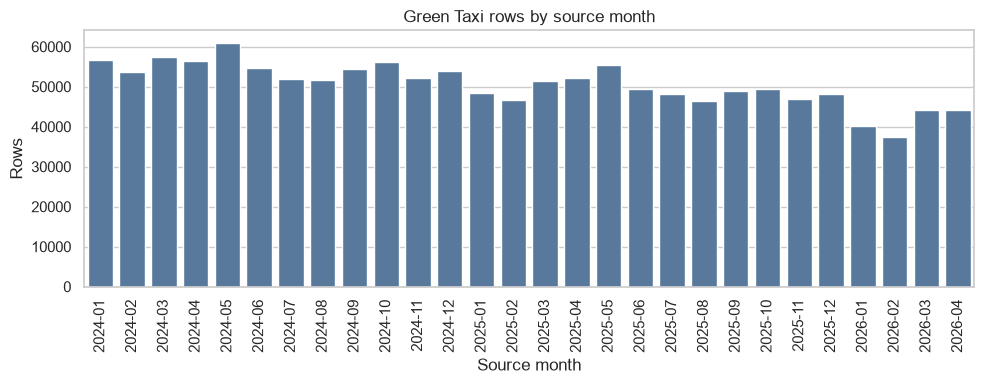

Saved plot: C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\monthly_row_counts.png


In [5]:
temporal_summary = monthly_temporal_summary(taxi)
display(temporal_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_metadata, x="period", y="row_count", color="#4C78A8")
plt.xticks(rotation=90)
plt.title("Green Taxi rows by source month")
plt.xlabel("Source month")
plt.ylabel("Rows")
plt.tight_layout()
row_count_plot = REPORT_DIR / "monthly_row_counts.png"
plt.savefig(row_count_plot, dpi=160)
plt.show()

print(f"Saved plot: {row_count_plot}")

## Data Validation

The checks below are evidence-gathering checks, not final production thresholds. Each finding is labeled as an observed fact, candidate expectation, or deferred decision.

In [6]:
missing_summary = missing_value_summary(taxi)
quality_summary = quality_check_summary(taxi)

display(missing_summary)
display(quality_summary)

top_quality_signals = quality_summary.sort_values("rows", ascending=False).head(10)
display(top_quality_signals)

,column,dtype,missing_count,missing_pct
0,ehail_fee,float64,1417684,100.000
1,cbd_congestion_fee,float64,664042,46.840
2,trip_type,float64,98122,6.921
3,RatecodeID,float64,97991,6.912
4,congestion_surcharge,float64,97991,6.912
5,passenger_count,float64,97991,6.912
6,payment_type,float64,97991,6.912
7,store_and_fwd_flag,str,97991,6.912
8,DOLocationID,int32,0,0.000
9,PULocationID,int32,0,0.000


,check,rows,finding_type,notes,total_rows,pct_rows
0,duplicate_full_rows,0,observed_fact,Exact duplicate records across all loaded columns.,1417684,0.000
1,missing_pickup_datetime,0,candidate_expectation,Pickup timestamp is required for any time-aware target or split.,1417684,0.000
2,missing_dropoff_datetime,0,candidate_expectation,Dropoff timestamp is needed for duration and post-trip validation.,1417684,0.000
3,non_positive_duration,2699,candidate_expectation,Trips with non-positive duration are invalid-looking for duration modeling.,1417684,0.190
4,duration_over_24_hours,2,deferred_decision,Very long trips need review before setting an outlier threshold.,1417684,0.000
5,negative_trip_distance,0,candidate_expectation,Negative distance is invalid-looking.,1417684,0.000
6,zero_trip_distance,64722,deferred_decision,Zero-distance trips may be invalid or special cases; defer filtering policy.,1417684,4.565
7,negative_fare_amount,4369,deferred_decision,Negative fares may reflect adjustments; defer policy until target selection.,1417684,0.308
8,negative_total_amount,4444,deferred_decision,Negative totals may reflect adjustments; defer policy until target selection.,1417684,0.313
9,missing_pickup_location,0,candidate_expectation,Pickup zone is expected for spatial features and serving examples.,1417684,0.000


,check,rows,finding_type,notes,total_rows,pct_rows
11,passenger_count_missing,97991,deferred_decision,Passenger count availability and imputation policy need profiling evidence.,1417684,6.912
6,zero_trip_distance,64722,deferred_decision,Zero-distance trips may be invalid or special cases; defer filtering policy.,1417684,4.565
12,passenger_count_zero_or_negative,17304,deferred_decision,Passenger count rules depend on target and serving assumptions.,1417684,1.221
8,negative_total_amount,4444,deferred_decision,Negative totals may reflect adjustments; defer policy until target selection.,1417684,0.313
7,negative_fare_amount,4369,deferred_decision,Negative fares may reflect adjustments; defer policy until target selection.,1417684,0.308
3,non_positive_duration,2699,candidate_expectation,Trips with non-positive duration are invalid-looking for duration modeling.,1417684,0.190
4,duration_over_24_hours,2,deferred_decision,Very long trips need review before setting an outlier threshold.,1417684,0.000
0,duplicate_full_rows,0,observed_fact,Exact duplicate records across all loaded columns.,1417684,0.000
2,missing_dropoff_datetime,0,candidate_expectation,Dropoff timestamp is needed for duration and post-trip validation.,1417684,0.000
1,missing_pickup_datetime,0,candidate_expectation,Pickup timestamp is required for any time-aware target or split.,1417684,0.000


## Exploratory Analysis

,column,count,mean,std,min,1%,5%,50%,95%,99%,max
0,trip_duration_minutes,1417684.0,20.363604,82.413801,-57.0,0.066667,2.683333,12.266667,39.016667,75.00,1500.766667
1,trip_distance,1417684.0,17.522291,1072.850444,0.0,0.000000,0.040000,1.930000,9.240000,17.14,262315.940000
2,fare_amount,1417684.0,17.999535,17.449406,-470.6,2.900000,4.400000,13.500000,45.000000,80.00,1422.600000
3,total_amount,1417684.0,24.710976,19.671448,-473.1,5.200000,9.000000,19.680000,56.900000,96.55,1424.100000
4,passenger_count,1319693.0,1.305429,0.962046,0.0,0.000000,1.000000,1.000000,3.000000,6.00,9.000000
5,PULocationID,1417684.0,96.640342,56.760728,1.0,7.000000,41.000000,75.000000,243.000000,260.00,265.000000
6,DOLocationID,1417684.0,141.961340,76.951036,1.0,7.000000,33.000000,140.000000,262.000000,264.00,265.000000


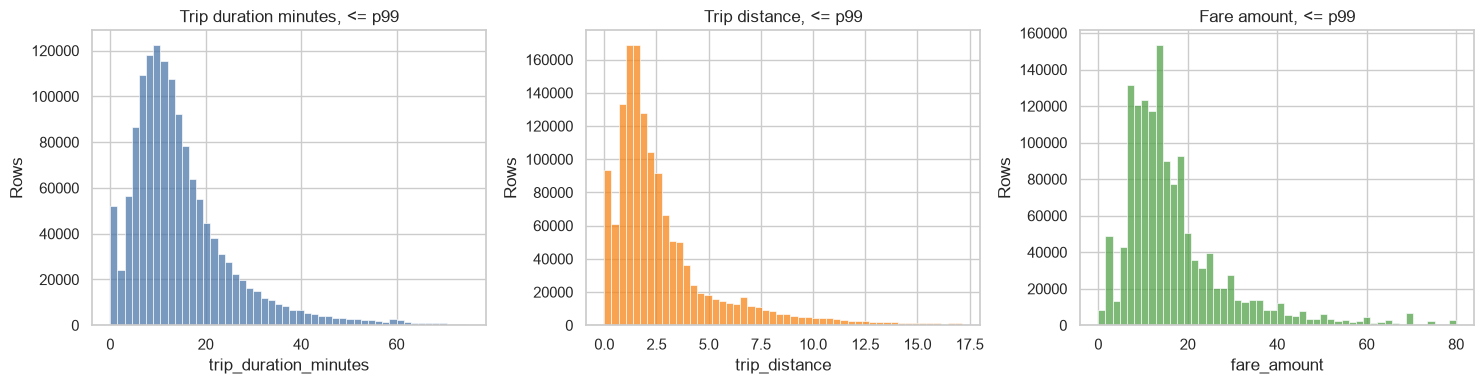

Saved plot: C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\candidate_target_distributions.png


In [7]:
numeric_summary = exploratory_numeric_summary(taxi)
display(numeric_summary)

plot_frame = taxi.copy()
duration_limit = plot_frame["trip_duration_minutes"].quantile(0.99)
distance_limit = plot_frame["trip_distance"].quantile(0.99)
fare_limit = plot_frame["fare_amount"].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(plot_frame.loc[plot_frame["trip_duration_minutes"].between(0, duration_limit), "trip_duration_minutes"], bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Trip duration minutes, <= p99")
sns.histplot(plot_frame.loc[plot_frame["trip_distance"].between(0, distance_limit), "trip_distance"], bins=50, ax=axes[1], color="#F58518")
axes[1].set_title("Trip distance, <= p99")
sns.histplot(plot_frame.loc[plot_frame["fare_amount"].between(0, fare_limit), "fare_amount"], bins=50, ax=axes[2], color="#54A24B")
axes[2].set_title("Fare amount, <= p99")
for ax in axes:
    ax.set_ylabel("Rows")
plt.tight_layout()
distribution_plot = REPORT_DIR / "candidate_target_distributions.png"
plt.savefig(distribution_plot, dpi=160)
plt.show()

print(f"Saved plot: {distribution_plot}")

In [8]:
categorical_columns = [column for column in ["VendorID", "RatecodeID", "payment_type", "trip_type"] if column in taxi.columns]
for column in categorical_columns:
    print(f"\n{column}")
    display(taxi[column].value_counts(dropna=False).head(15).reset_index().rename(columns={"index": column, column: "rows"}))

if ZONE_LOOKUP_PATH.exists():
    zones = pd.read_csv(ZONE_LOOKUP_PATH)
    display(zones.head())
    print(f"Taxi zone lookup rows: {len(zones):,}")
else:
    print(f"Taxi zone lookup not found: {ZONE_LOOKUP_PATH}")


VendorID


,rows,count
0,2,1212365
1,1,160582
2,6,44737



RatecodeID


,rows,count
0,1.0,1243314
1,NaN,97991
2,5.0,69882
3,2.0,3674
4,4.0,1565
5,3.0,840
6,99.0,409
7,6.0,9



payment_type


,rows,count
0,1.0,969332
1,2.0,337823
2,NaN,97991
3,3.0,9327
4,4.0,3159
5,5.0,52



trip_type


,rows,count
0,1.0,1253825
1,NaN,98122
2,2.0,65737


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Taxi zone lookup rows: 265


## Candidate Targets

The table below assesses target availability only. The final target remains deferred until quality, leakage, serving feasibility, and modeling evidence are considered together.

In [9]:
target_summary = candidate_target_summary(taxi)
display(target_summary)

,candidate_target,usable_rows,usable_pct,decision_status,notes
0,trip_duration_minutes,1414985,99.810,deferred,Regression target from pickup/dropoff timestamps; not known before trip completion.
1,fare_amount,1417684,100.000,deferred,Regression target from metered fare; post-trip field.
2,total_amount,1417684,100.000,deferred,Regression target for total paid amount; includes post-trip components.
3,long_trip_indicator,354343,24.994,deferred,Classification target candidate based on duration quantile; threshold is exploratory only.
4,high_fare_indicator,343130,24.204,deferred,Classification target candidate based on fare quantile; threshold is exploratory only.


## Serving-Time Features

Serving inputs must avoid leakage from post-trip fields such as fare components, payment details, dropoff timestamp, and measured trip distance. The classification below is an initial review, not the final serving schema.

In [10]:
serving_columns = serving_time_column_classification(taxi.columns)
display(serving_columns.sort_values(["availability", "column"]))
display(serving_columns["availability"].value_counts().reset_index().rename(columns={"index": "availability", "availability": "columns"}))

,column,availability,rationale
21,source_month,metadata_only,"Local profiling metadata, not a model input."
22,source_period,metadata_only,"Local profiling metadata, not a model input."
20,source_year,metadata_only,"Local profiling metadata, not a model input."
0,VendorID,needs_review,Operational field; availability depends on integration design.
25,pickup_date,needs_review,Not classified yet.
26,pickup_hour,needs_review,Not classified yet.
3,store_and_fwd_flag,needs_review,Operational field; availability depends on integration design.
23,cbd_congestion_fee,post_trip_only,Known only after trip completion or payment; avoid as serving input.
19,congestion_surcharge,post_trip_only,Known only after trip completion or payment; avoid as serving input.
14,ehail_fee,post_trip_only,Known only after trip completion or payment; avoid as serving input.


,columns,count
0,post_trip_only,14
1,serving_candidate,6
2,needs_review,4
3,metadata_only,3


## Artifacts Saved

In [11]:
saved_artifacts = save_artifacts(
    {
        "monthly_metadata": monthly_metadata,
        "schema_by_period": schema,
        "schema_presence_summary": schema_summary,
        "missing_value_summary": missing_summary,
        "quality_check_summary": quality_summary,
        "temporal_summary": temporal_summary,
        "numeric_summary": numeric_summary,
        "candidate_target_summary": target_summary,
        "serving_time_column_classification": serving_columns,
    },
    REPORT_DIR,
)

pd.DataFrame([{"artifact": name, "path": path} for name, path in saved_artifacts.items()])

,artifact,path
0,monthly_metadata,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\monthly_metadata.csv
1,schema_by_period,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\schema_by_period.csv
2,schema_presence_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\schema_presence_summary.csv
3,missing_value_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\missing_value_summary.csv
4,quality_check_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\quality_check_summary.csv
5,temporal_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\temporal_summary.csv
6,numeric_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\numeric_summary.csv
7,candidate_target_summary,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\candidate_target_summary.csv
8,serving_time_column_classification,C:\Users\Asus\Documents\MLOPS Project\mlops-project\data\08_reporting\profiling\serving_time_column_classification.csv


## Conclusions and Production Notes

- The project has local monthly Green Taxi parquet files suitable for profiling and later batch-oriented MLOps demonstrations.
- Schema stability must be handled explicitly because `cbd_congestion_fee` is not available in all months.
- Duration, distance, fare, payment, passenger, and location fields show the quality dimensions that later data tests should enforce or monitor.
- Candidate targets remain open: duration and fare-related targets are feasible candidates, but the final choice should consider leakage, serving-time inputs, outliers, and business usefulness.
- Serving features must exclude post-trip fields. The next notebook should develop feature engineering from serving-candidate fields and document any local feature-store fallback.
- Final decisions still deferred: target, split months, validation thresholds, outlier policy, model metric, feature set, baseline model, drift reference/current periods, and production alert thresholds.